In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [2]:
# -------------------------
# LOAD DATA
df_init = pd.read_csv("../data/final_table.csv")

SQ_ref_proteins = pd.read_csv('../data/SQ_ref_enzymes.tsv', sep='\t')

meta_table = pd.read_csv('../data/SQ_metatable_all.tsv', sep='\t')

meta = meta_table.merge(
    SQ_ref_proteins,
    left_on='query',
    right_on='Protein ID',
    how='left'  # left join - сохраняем все строки из mata_table
)
# -------------------------
# FAST EXPLODE

df_expanded = (
    df_init.assign(target=df_init["target"].str.split(","))
    .explode("target")
    .rename(columns={"SQ_pathway": "pathway", "SQ_score": "score"})
    [["cluster", "contig", "target", "pathway", "score", "taxonomy"]]
)

# -------------------------
# MERGE META

df = df_expanded.merge(
    meta[["target", "Gene", "MAG"]],
    on="target",
    how="left"
)

# -------------------------
# TAXONOMY EXTRACTION

def extract_rank(series, rank):
    return (
        series.str.split(";")
        .apply(lambda lst: next(
            (x.split("__")[1] for x in lst if x.startswith(rank + "__")),
            "Unknown"
        ))
    )

ranks = {
    "d": "Domain",
    "p": "Phylum",
    "c": "Class",
    "o": "Order",
    "f": "Family",
    "g": "Genus",
    "s": "Species"
}

for k, v in ranks.items():
    df[v] = extract_rank(df["taxonomy"], k)

tax_cols = list(ranks.values())

# -------------------------
# UNIQUE GENE PRESENCE

df_unique = df.drop_duplicates(subset=["MAG", "Gene"])[["MAG", "Gene"] + tax_cols]

# -------------------------
# PRESENCE / ABSENCE MATRIX

presence_matrix = (
    df_unique
    .assign(val=1)
    .pivot_table(
        index="MAG",
        columns="Gene",
        values="val",
        fill_value=0
    )
)

print("Presence matrix shape:", presence_matrix.shape)

Presence matrix shape: (323, 23)


In [3]:
# -------------------------
# GENE FREQUENCY

gene_freq = presence_matrix.sum(axis=0)

print("Редкие гены:")
print(gene_freq.sort_values().head())

print("\nЧастые гены:")
print(gene_freq.sort_values().tail())

Редкие гены:
Gene
sedB    1.0
sedC    1.0
sqwD    1.0
yihS    1.0
ssuE    2.0
dtype: float64

Частые гены:
Gene
sqwH    115.0
sqwG    122.0
sqvD    131.0
sqiA    162.0
sqvA    163.0
dtype: float64


In [4]:
# -------------------------
# JACCARD FUNCTION

def compute_jaccard(X):
    X_bin = X.astype(bool).astype(int)

    intersection = X_bin.T @ X_bin
    counts = X_bin.sum(axis=0).values

    union = np.add.outer(counts, counts) - intersection.values
    union = union.astype(float)
    union[union == 0] = np.nan

    jaccard = pd.DataFrame(
        intersection.values / union,
        index=X.columns,
        columns=X.columns
    ).fillna(0)

    np.fill_diagonal(jaccard.values, 0)
    return jaccard

# -------------------------
# GLOBAL JACCARD

jaccard = compute_jaccard(presence_matrix)

print("Shape:", jaccard.shape)
print("Min/Max:", jaccard.min().min(), jaccard.max().max())
print("Symmetric:", (jaccard.values == jaccard.values.T).all())

Shape: (23, 23)
Min/Max: 0.0 0.8372093023255814
Symmetric: True


/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


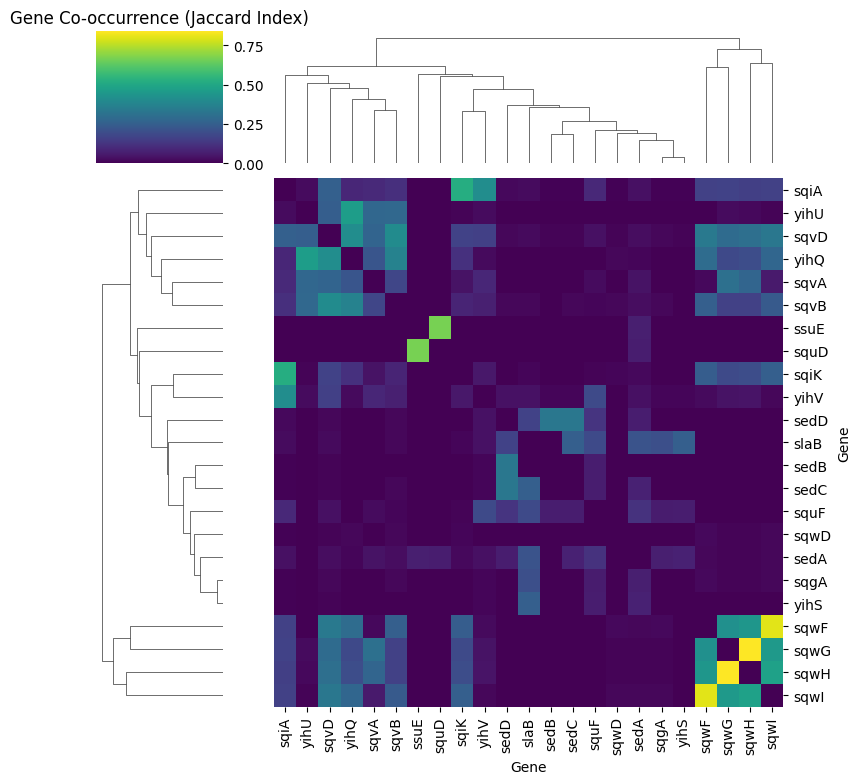

In [5]:
# -------------------------
# CLUSTERMAP

sns.clustermap(
    jaccard,
    cmap="viridis",
    figsize=(8, 9),
    metric="euclidean",
    method="average",
    cbar_pos = (0, 1, 0.2, 0.1),
    xticklabels=1,
    yticklabels=1
)

plt.title("Gene Co-occurrence (Jaccard Index)")
plt.tight_layout()
plt.savefig("../pictures/co-occurence/heatmap.png", dpi=300)
plt.show()

/tmp/ipykernel_15614/1714561835.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


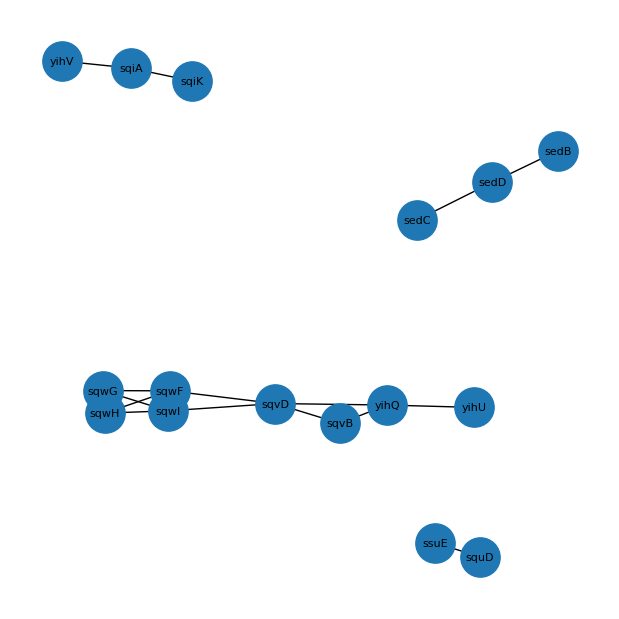

In [6]:
# -------------------------
# NETWORK

threshold = 0.32

mask = jaccard.values > threshold
rows, cols = np.where(mask)

edges = [
    (jaccard.index[i], jaccard.columns[j], jaccard.values[i, j])
    for i, j in zip(rows, cols) if i != j
]

G = nx.Graph()
G.add_weighted_edges_from(edges)

plt.figure(figsize=(6, 6))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=800,
    font_size=8
)

plt.tight_layout()
plt.savefig("../pictures/co-occurence/network.png", dpi=300)
plt.show()

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


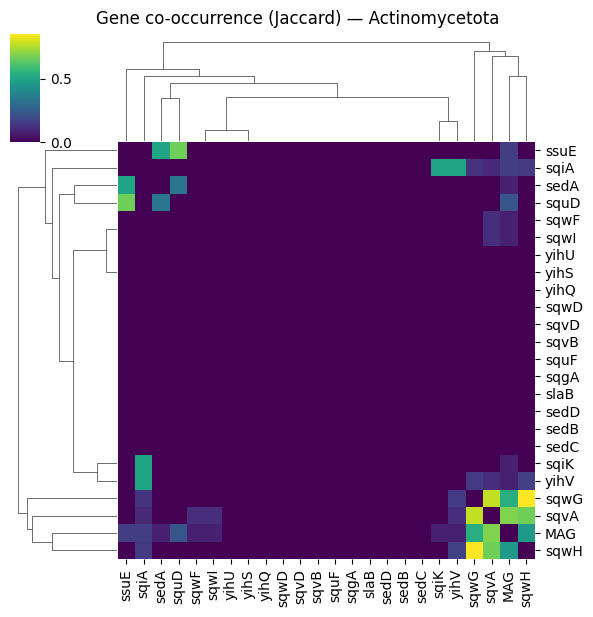

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


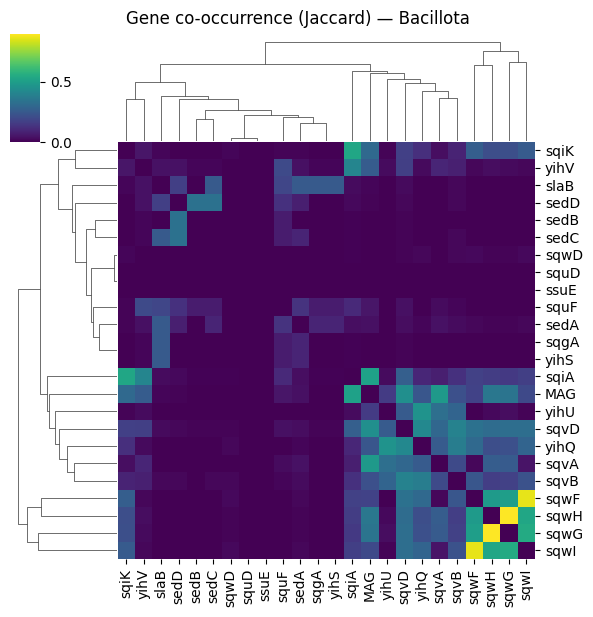

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


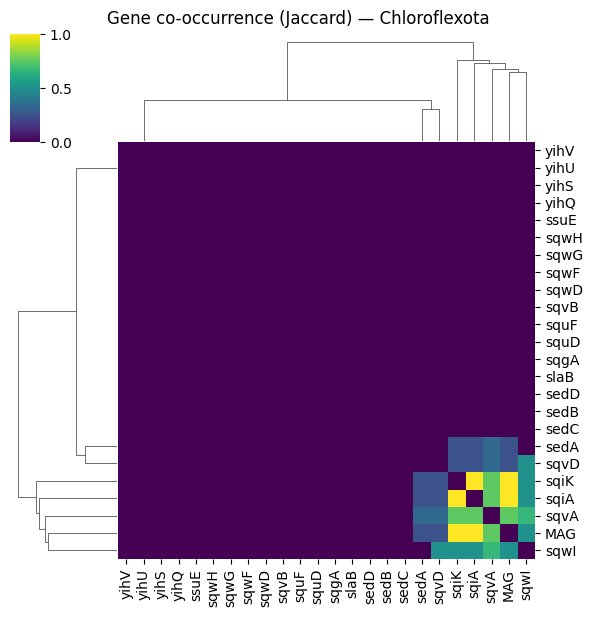

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


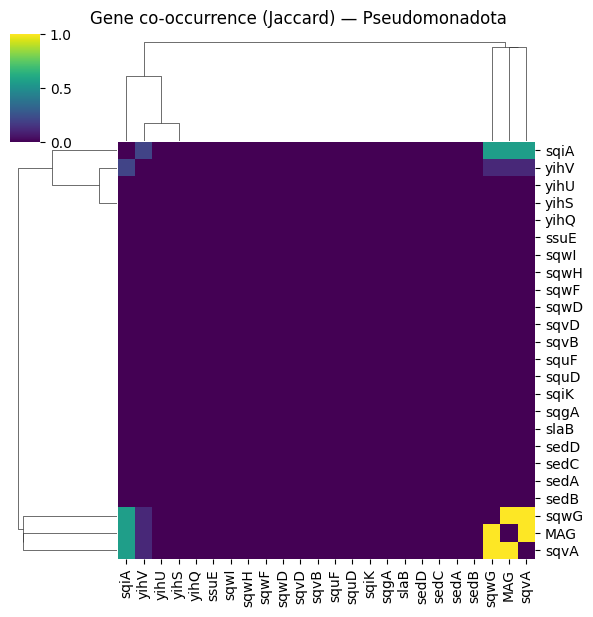

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


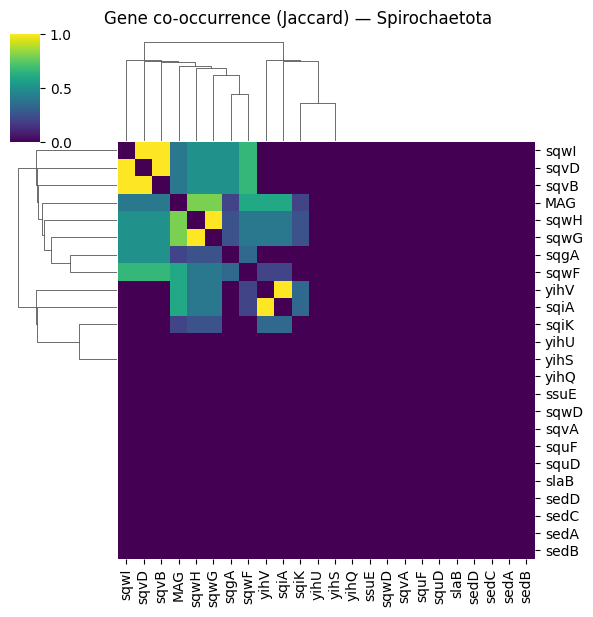

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


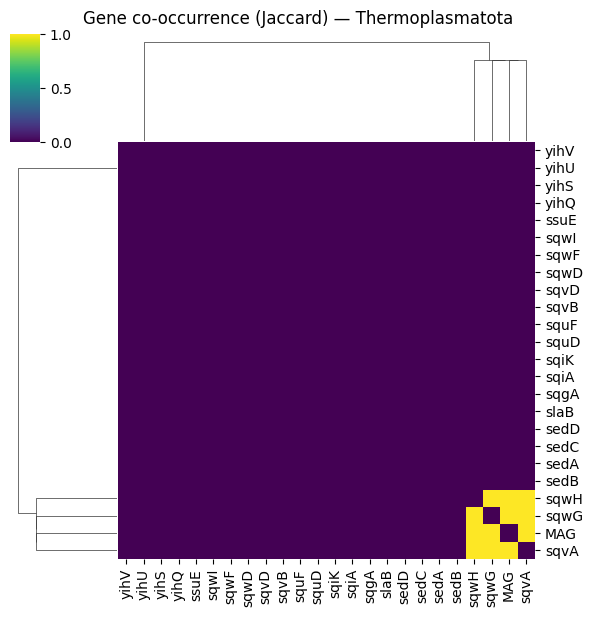

Skipping Verrucomicrobiota (too few MAGs)


In [7]:
# -------------------------
# PHYLA-SPECIFIC ANALYSIS

presence_matrix = presence_matrix.merge(
    df[["MAG", "Phylum"]].drop_duplicates(),
    on="MAG",
    how="left"
)

target_phyla = [
    "Actinomycetota",
    "Bacillota",
    "Chloroflexota",
    "Pseudomonadota",
    "Spirochaetota",
    "Thermoplasmatota",
    "Verrucomicrobiota"
]

filtered_matrix = presence_matrix[
    presence_matrix["Phylum"].isin(target_phyla)
]

for phylum, group in filtered_matrix.groupby("Phylum"):

    mat = group.drop(columns=tax_cols, errors="ignore") # только гены

    if mat.shape[0] < 3:
        print(f"Skipping {phylum} (too few MAGs)")
        continue

    # Jaccard
    jaccard_phylum = compute_jaccard(mat)

    if jaccard_phylum.shape[0] < 3:
        print(f"Skipping {phylum} (too few genes)")
        continue

    # Clustermap
    g = sns.clustermap(
        jaccard_phylum,
        cmap="viridis",
        figsize=(6, 6),
        method="average",
        metric="euclidean",
        xticklabels=1,
        yticklabels=1
    )

    g.fig.suptitle(f"Gene co-occurrence (Jaccard) — {phylum}", y=1.02)
    
    filename = f"clustermap_{phylum.replace(' ', '_')}.png"
    plt.savefig(f"../pictures/co-occurence/{filename}", dpi=300)
    plt.show()